In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [4]:
# Create a Model Class that inherits nn.Module
class Model(nn.Module):
    # Input layer (4 features of the flower) --->
    # Hidden Layer1 (number of neurons) --->  
    # H2 (n) --->
    # output (3 classes of iris flowers)
    def __init__(self, in_features=4, h1=9, h2=9, out_features=3):
        super().__init__() #instantiate our nn.Module
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        
        return x

In [6]:
#Pick a manual seed for randomization
torch.manual_seed(41)
#Create an instance of model
model = Model()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)

In [9]:
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [12]:
my_df['species'] = my_df['species'].replace('setosa', 0.0)
my_df['species'] = my_df['species'].replace('versicolor', 1.0)
my_df['species'] = my_df['species'].replace('virginica', 2.0)
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [13]:
# Train Test Split! Set X, y
X = my_df.drop('species', axis=1)
y = my_df['species']

#Convert these to numpy arrays
X = X.values
y = y.values

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [17]:
#Convert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [18]:
#Convert y labels to tensors long
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [19]:
#Set the criterion of model to measure the error, how far off the predictions are from the data

In [20]:
criterion = nn.CrossEntropyLoss()
#Choose Adam Optimizer, lr = learning rate (if error doesn't go down after a bunch of iterations (epoch), lower the learning rate)

In [21]:
optimizer = torch.optim.Adam(model.parameters(),  lr=0.01)

In [24]:
# Train our model
# Epoch? (one run thru all the training data in our networks)
epochs = 100
losses = []
for i in range(epochs):
    # Go forward and get a prediction
    y_pred = model.forward(X_train) #Get predictive results
    
    # Measure the loss/error, gonna be high at first
    loss = criterion(y_pred, y_train) #predicted values vs the y_train
    
    # Keep Track of our losses
    losses.append(loss.detach().numpy())
    
    # print every 10 epoch
    if i % 10 == 0:
        print(f'Epoch: {i} and loss: {loss}')
        
    # Do some back propogation: take the error rate of forward propogation
    # and feed it back thru the network to fine tune the wreights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch: 0 and loss: 1.1246826648712158
Epoch: 10 and loss: 0.9470431208610535
Epoch: 20 and loss: 0.6978070735931396
Epoch: 30 and loss: 0.4602702558040619
Epoch: 40 and loss: 0.3046573996543884
Epoch: 50 and loss: 0.18159160017967224
Epoch: 60 and loss: 0.10772991180419922
Epoch: 70 and loss: 0.07273149490356445
Epoch: 80 and loss: 0.05569281801581383
Epoch: 90 and loss: 0.046284448355436325


Text(0.5, 0, 'Epoch')

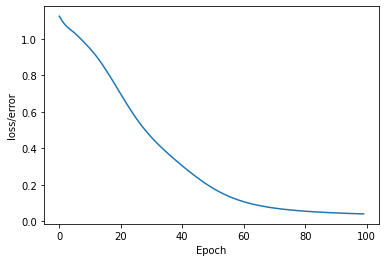

In [25]:
#Graph it out!
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel("Epoch")

In [26]:
# Evaluate Model on Test Data Set (validate model on test set)
with torch.no_grad():  # Basically turn off your back propogation
    y_eval = model.forward(X_test) 
    loss = criterion(y_eval, y_test) #Find the loss or error

In [27]:
loss

tensor(0.1401)

In [30]:
correct = 0
with torch.no_grad():
    for i, data in enumerate(X_test):
        y_val = model.forward(data)
        
        # Will tell you what type of flower class our network thinks it is
        print(f'{i+1}.) {str(y_val)} \t {y_test[i]}')
    
        # Correct or not
        if y_val.argmax().item() == y_test[i]:
            correct += 1
print(f'We got {correct} correct!')

1.) tensor([-6.5606,  4.0581,  7.6100]) 	 2
2.) tensor([-9.4694,  3.5387, 10.7735]) 	 2
3.) tensor([-9.5088,  4.4513, 11.0074]) 	 2
4.) tensor([-1.1191,  6.3173,  1.8912]) 	 1
5.) tensor([-7.7045,  4.5291,  8.9941]) 	 2
6.) tensor([ 1.8660,  7.2522, -1.2929]) 	 1
7.) tensor([-5.2724,  4.9190,  6.3270]) 	 2
8.) tensor([-0.6632,  6.6060,  1.4386]) 	 1
9.) tensor([-6.4078,  4.7912,  7.5834]) 	 2
10.) tensor([-9.8678,  3.8422, 11.2876]) 	 2
11.) tensor([-4.8318,  5.0805,  5.8591]) 	 2
12.) tensor([ 18.5472,  12.6293, -18.8578]) 	 0
13.) tensor([ 16.5823,  11.3705, -16.8895]) 	 0
14.) tensor([ 2.5898,  6.6207, -2.2175]) 	 1
15.) tensor([ 16.1908,  11.7761, -16.4548]) 	 0
16.) tensor([-4.3525,  5.2453,  5.3334]) 	 2
17.) tensor([ 16.5789,  11.6352, -16.8725]) 	 0
18.) tensor([-6.0062,  4.4698,  7.0603]) 	 1
19.) tensor([ 17.6528,  12.0651, -17.9649]) 	 0
20.) tensor([ 14.4779,  10.3987, -14.7613]) 	 0
21.) tensor([ 2.1691,  6.8079, -1.7188]) 	 1
22.) tensor([-8.9106,  4.2768, 10.3101]) 	 2
2

In [31]:
new_iris = torch.tensor([4.7, 3.2, 1.3, 0.2])

In [32]:
with torch.no_grad():
    print(model(new_iris))

tensor([ 17.8465,  12.0881, -18.1606])


In [33]:
newer_iris = torch.tensor([5.9, 3.0, 5.1, 1.8])

In [34]:
with torch.no_grad():
    print(model(newer_iris))

tensor([-6.3871,  4.4279,  7.4887])


In [35]:
# Save our NN Model

In [38]:
torch.save(model.state_dict(), 'my_really_awesome_iris_model.pt')

In [39]:
new_model = Model()
new_model.load_state_dict(torch.load('my_really_awesome_iris_model.pt'))

<All keys matched successfully>

In [40]:
# Make sure it loaded correctly
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=9, bias=True)
  (fc2): Linear(in_features=9, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)